# 🫀 HeartGAPSO: End-to-End Heart Disease Prediction Pipeline
### Hybrid Genetic Algorithm (GA) & Particle Swarm Optimization (PSO) for Feature Selection and Hyperparameter Tuning

This notebook provides a complete, self-contained pipeline for training, evaluating, and deploying the **HeartGAPSO** machine learning system on the UCI Cleveland Heart Disease dataset.

---

### 📌 Pipeline Architecture Overview
```
┌──────────────────────────────────────────────────────────┐
│ 1. Load UCI Cleveland Data (303 rows, 13 features)       │
│    Convert targets (0 = Healthy, 1..4 = Heart Disease)   │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 2. Stratified 80/20 Train-Test Split (Untouched Holdout) │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 3. Training-Only Statistical Analysis ($T^2$ Scoring)    │
│    Prioritize key features: cp, slope, ca, thal          │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 4. Hybrid GA-PSO Optimization                            │
│    - Joint feature selection (13-bit chromosome)         │
│    - Random Forest hyperparameter tuning                 │
│    - Fast screening + High-fidelity stability audit      │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 5. Final Model Fit & Threshold Optimization              │
│    Fold-local Median Imputation & MinMax Normalization   │
└─────────────────────────────┬────────────────────────────┘
                              │
┌─────────────────────────────▼────────────────────────────┐
│ 6. Holdout Evaluation & Clinical Inference Pipeline      │
│    ROC-AUC, Confusion Matrix, Patient Risk Prediction    │
└──────────────────────────────────────────────────────────┘
```


## 1. Setup & Environment Configuration
Importing required data science libraries, optimization modules, and configuring random seeds for complete reproducibility.


In [5]:
# Install all necessary dependencies into the active notebook kernel
%pip install -q numpy pandas scikit-learn matplotlib ucimlrepo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import sys
import json
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    auc
)

# Add project root to sys.path if needed
sys.path.insert(0, str(Path.cwd()))

# Import modular components from src
from src.data_loader import FEATURE_NAMES, load_cleveland
from src.preprocessing import make_preprocessor
from src.statistical_analysis import analyze_features, save_analysis
from src.fitness import FitnessConfig
from src.genetic_algorithm import GAConfig
from src.gapso_optimizer import optimize
from src.random_forest import InferencePipeline, make_random_forest
from src.evaluation import evaluate_model, save_optimization_diagnostics

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Environment initialized successfully.")


✓ Environment initialized successfully.


## 2. Dataset Loading & Exploratory Data Analysis (EDA)
Loading the Cleveland Heart Disease dataset (`heart+disease/processed.cleveland.data`).
- Features: 13 clinical biomarkers (e.g., `age`, `chol`, `thalach`, `cp`, `ca`, `thal`, etc.)
- Target: Multiclass values `0` (absence) and `1, 2, 3, 4` (presence) mapped to binary classification ($0$ vs $1$).


In [7]:
DATA_PATH = Path("heart+disease/processed.cleveland.data")

# Load full dataset with standard binary mapping
X, y = load_cleveland(DATA_PATH)

df_preview = X.copy()
df_preview["target"] = y

print(f"Dataset Shape: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Class Distribution:")
print(f" - Healthy (Class 0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f" - Heart Disease (Class 1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

# Display first 5 rows
df_preview.head()


Dataset Shape: 303 rows, 13 features
Class Distribution:
 - Healthy (Class 0): 164 (54.1%)
 - Heart Disease (Class 1): 139 (45.9%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


,count,mean,std,min,50%,max
age,303.0,54.438944,9.038662,29.0,56.0,77.0
sex,303.0,0.679868,0.467299,0.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,130.0,200.0
chol,303.0,246.693069,51.776918,126.0,241.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,1.0,2.0
thalach,303.0,149.607261,22.875003,71.0,153.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.8,6.2


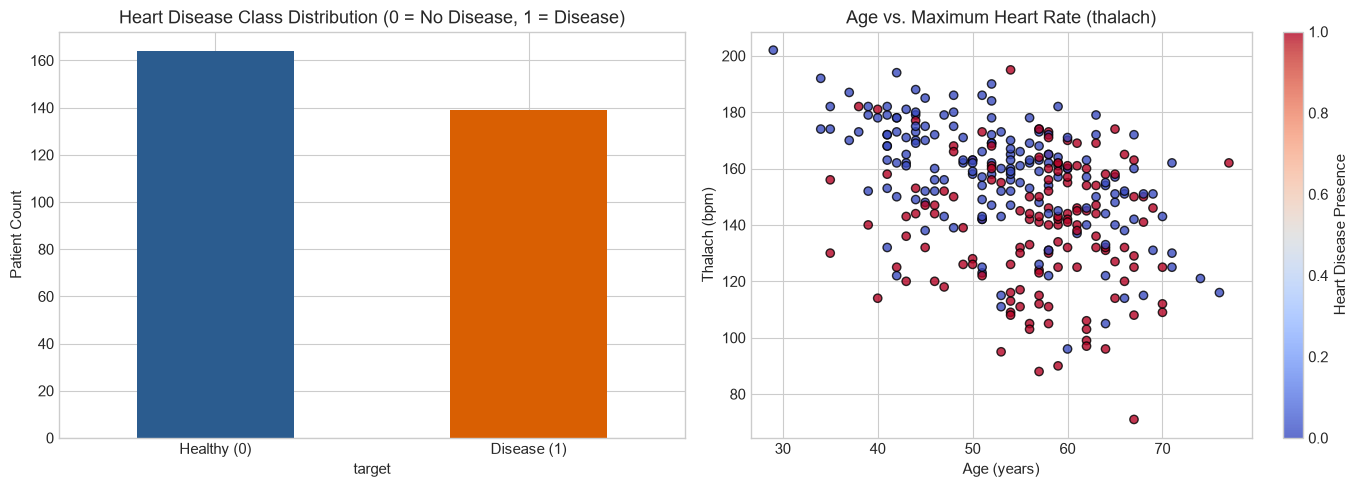

In [8]:
# Summary statistics
display(df_preview.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#d95f02'])
axes[0].set_title("Heart Disease Class Distribution (0 = No Disease, 1 = Disease)")
axes[0].set_xticklabels(["Healthy (0)", "Disease (1)"], rotation=0)
axes[0].set_ylabel("Patient Count")

# Age vs Max Heart Rate (thalach) colored by target
scatter = axes[1].scatter(X['age'], X['thalach'], c=y, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[1].set_title("Age vs. Maximum Heart Rate (thalach)")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Thalach (bpm)")
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Heart Disease Presence")

plt.tight_layout()
plt.show()


## 3. Stratified Train-Test Split (Untouched Holdout)
To prevent data leakage and guarantee valid external generalization, 20% of the data is held out prior to any statistical analysis, feature selection, or hyperparameter optimization.


In [9]:
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Holdout test set: {X_test.shape[0]} samples")


Training set: 242 samples
Holdout test set: 61 samples


## 4. Statistical Feature Significance Analysis ($T^2$ Scoring)
Computing training-only class statistics, pooled variances, and $T^2$ scores to measure how strongly individual features separate the two patient cohorts.
Features with high statistical scores (such as `cp`, `slope`, `ca`, `thal`) are used to seed the initial Genetic Algorithm population.


,importance_rank,feature,t2_statistical_score,class_0_mean,class_1_mean,mutation_probability
0,1,thal,104.357305,3.732824,5.881818,0.001
1,2,ca,61.737010,0.244275,1.045455,0.001
2,3,exang,51.486909,0.145038,0.540541,0.080
3,4,thalach,48.347133,158.496183,139.891892,0.080
4,5,cp,45.883288,2.793893,3.576577,0.001
5,6,oldpeak,43.615028,0.594656,1.476577,0.080
6,7,slope,28.023125,1.404580,1.801802,0.001
7,8,sex,25.215352,0.549618,0.837838,0.080
8,9,age,11.035221,52.816794,56.594595,0.080
9,10,restecg,6.334802,0.832061,1.153153,0.080


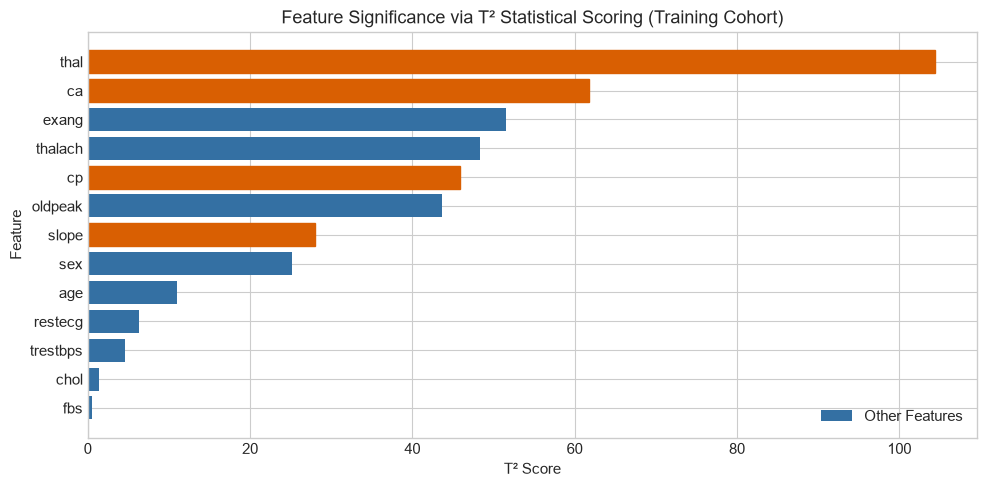

✓ Top statistically significant features identified: ['ca', 'cp', 'slope', 'thal']


In [10]:
# Compute statistical significance on training partition only
statistical_analysis = analyze_features(X_train, y_train)

# Convert to DataFrame for clear visualization
stats_df = pd.DataFrame(statistical_analysis["features"])
display(stats_df[["importance_rank", "feature", "t2_statistical_score", "class_0_mean", "class_1_mean", "mutation_probability"]])

# Plot T² feature scores
plt.figure(figsize=(10, 5))
sorted_stats = stats_df.sort_values(by="t2_statistical_score", ascending=True)
bars = plt.barh(sorted_stats["feature"], sorted_stats["t2_statistical_score"], color="#3470a3")
plt.title("Feature Significance via T² Statistical Scoring (Training Cohort)")
plt.xlabel("T² Score")
plt.ylabel("Feature")

# Highlight paper-seeded features
for bar, feat in zip(bars, sorted_stats["feature"]):
    if feat in statistical_analysis["important_features"]:
        bar.set_color("#d95f02")

plt.legend(["Other Features", "Statistically Seeded (cp, slope, ca, thal)"], loc="lower right")
plt.tight_layout()
plt.show()

# Save artifact
save_analysis(statistical_analysis, "artifacts/statistical_feature_analysis.json")
print(f"✓ Top statistically significant features identified: {statistical_analysis['important_features']}")


## 5. Hybrid GAPSO Optimization Execution
The hybrid Genetic Algorithm + Particle Swarm Optimization framework simultaneously optimizes:
1. **Feature Subset Selection**: Binary mask over all 13 features.
2. **Random Forest Hyperparameters**: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `class_weight`.

The fitness objective balances multi-metric diagnostic power:
$$\text{Fitness} = 0.40 \cdot \text{ROC-AUC} + 0.25 \cdot F_1 + 0.20 \cdot \text{Sensitivity} + 0.15 \cdot \text{Specificity} - \lambda_{\text{sparsity}} \cdot |S| - \lambda_{\text{stability}} \cdot \sigma_{\text{CV}}$$


In [15]:
# Optimization Configuration parameters
FITNESS_CONFIG = FitnessConfig(
    folds=5,
    repeats=3,
    roc_auc_weight=0.40,
    f1_weight=0.25,
    sensitivity_weight=0.20,
    specificity_weight=0.15
)

GA_CONFIG = GAConfig(
    population_size=50,
    generations=40,
    pso_iterations=20,
    max_evaluations=800,
    pso_particles=20
)

print("Starting GAPSO Optimization...")
print(f" - Population Size: {GA_CONFIG.population_size}")
print(f" - Max Generations: {GA_CONFIG.generations}")
print(f" - PSO Iterations: {GA_CONFIG.pso_iterations}")
print(f" - Max Evaluation Budget: {GA_CONFIG.max_evaluations}")

start_time = time.perf_counter()
opt_result = optimize(
    X=X_train,
    y=y_train,
    seed=RANDOM_SEED,
    ga_config=GA_CONFIG,
    fitness_config=FITNESS_CONFIG,
    high_fidelity_candidate_limit=30,
    stability_candidates=5,
    fast_promotions=30,
    stability_seeds=5,
    statistical_analysis=statistical_analysis,
)


opt_runtime = time.perf_counter() - start_time

selected_feature_indices = [idx for idx, bit in enumerate(opt_result["features"]) if bit]
selected_feature_names = [FEATURE_NAMES[idx] for idx in selected_feature_indices]

print(f"\nOptimization completed in {opt_runtime:.2f} seconds!")
print(f"Best Fitness Score: {opt_result['fitness']:.4f}")
print(f"Selected Features ({len(selected_feature_names)}/13): {selected_feature_names}")
print(f"Optimal Hyperparameters: {json.dumps(opt_result['params'], indent=2)}")
print(f"Optimal Decision Threshold: {opt_result['threshold']:.3f}")


Starting GAPSO Optimization...
 - Population Size: 50
 - Max Generations: 40
 - PSO Iterations: 20
 - Max Evaluation Budget: 800
[GA/PSO] Evaluating fast candidate 1/800 | trees=400 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 2/800 | trees=100 | features=11 | CV=3x1
[GA/PSO] Evaluating fast candidate 3/800 | trees=400 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 4/800 | trees=300 | features=11 | CV=3x1
[GA/PSO] Evaluating fast candidate 5/800 | trees=300 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 6/800 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 7/800 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 8/800 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 9/800 | trees=300 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 10/800 | trees=400 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 11/800 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 12/800 

## 6. Optimization Diagnostics & Convergence Analysis
Visualizing convergence curves across generations, feature sparsity evolution, and candidate audit rankings.


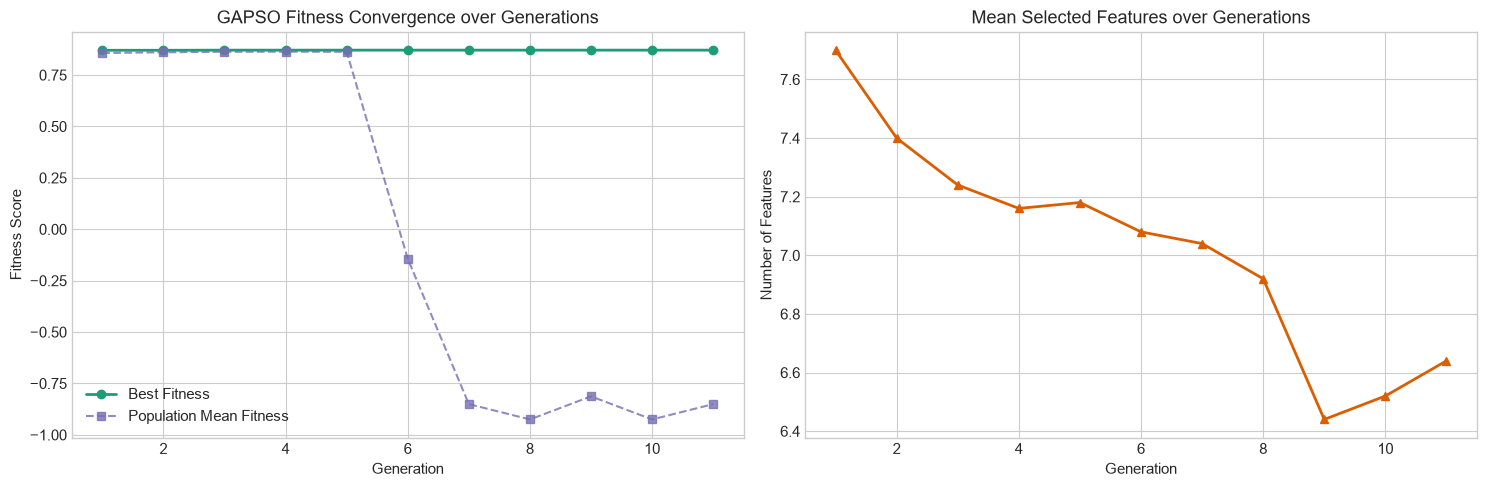

,candidate_id,fast_rank,screening_rank,final_rank,screening_fitness,final_fitness
0,25,25,1,1.0,0.864109,0.864525
1,26,26,2,2.0,0.863960,0.864481
2,1,1,3,5.0,0.860114,0.858087
3,19,19,4,3.0,0.859390,0.862189
4,20,20,5,4.0,0.859390,0.862189
5,22,22,6,NaN,0.856638,NaN
6,29,29,7,NaN,0.855495,NaN
7,30,30,8,NaN,0.855495,NaN
8,27,27,9,NaN,0.855363,NaN
9,28,28,10,NaN,0.855363,NaN


In [16]:
history = opt_result.get("history", [])

if history:
    generations = [item["generation"] for item in history]
    best_fitness_curve = [item["best_fitness"] for item in history]
    mean_fitness_curve = [item["mean_fitness"] for item in history]
    mean_features_curve = [np.mean(item["selected_feature_counts"]) for item in history]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Fitness convergence
    axes[0].plot(generations, best_fitness_curve, 'o-', color='#1b9e77', label='Best Fitness', linewidth=2)
    axes[0].plot(generations, mean_fitness_curve, 's--', color='#7570b3', label='Population Mean Fitness', alpha=0.8)
    axes[0].set_title("GAPSO Fitness Convergence over Generations")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Fitness Score")
    axes[0].legend()

    # Feature sparsity evolution
    axes[1].plot(generations, mean_features_curve, '^-', color='#d95f02', linewidth=2)
    axes[1].set_title("Mean Selected Features over Generations")
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Number of Features")

    plt.tight_layout()
    plt.show()

# Display Top Candidate Audit Summary
candidate_audit = pd.DataFrame(opt_result["candidate_audit"])
if not candidate_audit.empty:
    display_cols = ["candidate_id", "fast_rank", "screening_rank", "final_rank", "screening_fitness", "final_fitness", "selected_feature_count"]
    present_cols = [c for c in display_cols if c in candidate_audit.columns]
    display(candidate_audit[present_cols].head(10))


## 7. Final Model Training & Pipeline Assembly
Fitting the final Random Forest model on the training set using the optimal feature subset and hyperparameters, and packaging with preprocessing into a self-contained `InferencePipeline`.


In [17]:
# 1. Fit Preprocessor (Median Imputation & MinMax Normalization) on selected features
preprocessor = make_preprocessor()
X_train_selected = X_train.iloc[:, selected_feature_indices]
X_train_processed = preprocessor.fit_transform(X_train_selected)

# 2. Instantiate and train Random Forest with optimal hyperparameters
final_rf = make_random_forest(opt_result["params"], RANDOM_SEED)
final_rf.fit(X_train_processed, y_train)

# 3. Create complete Inference Pipeline
pipeline = InferencePipeline(
    preprocessing=preprocessor,
    classifier=final_rf,
    indices=selected_feature_indices,
    threshold=opt_result["threshold"]
)

print("✓ Final Inference Pipeline successfully trained and assembled.")


✓ Final Inference Pipeline successfully trained and assembled.


## 8. Holdout Set Evaluation & Performance Metrics
Evaluating the trained model on the **untouched 20% holdout test partition** ($N = 61$). All metrics and curves reflect single-pass independent holdout evaluation.


In [18]:
# Predict probabilities and binary labels on untouched test holdout
X_test_selected = X_test.iloc[:, selected_feature_indices]
y_test_prob = pipeline.predict_proba(X_test)[:, 1]
y_test_pred = pipeline.predict(X_test)

# Calculate performance metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)

metrics_summary = {
    "Accuracy": acc,
    "ROC-AUC": roc_auc,
    "Sensitivity / Recall": rec,
    "Specificity": spec,
    "Precision": prec,
    "F1-Score": f1,
    "Classification Threshold": opt_result["threshold"]
}

metrics_df = pd.DataFrame(list(metrics_summary.items()), columns=["Metric", "Holdout Value"])
display(metrics_df.style.format({"Holdout Value": "{:.4f}"}))


,Metric,Holdout Value
0,Accuracy,0.8361
1,ROC-AUC,0.9221
2,Sensitivity / Recall,0.8929
3,Specificity,0.7879
4,Precision,0.7812
5,F1-Score,0.8333
6,Classification Threshold,0.4500


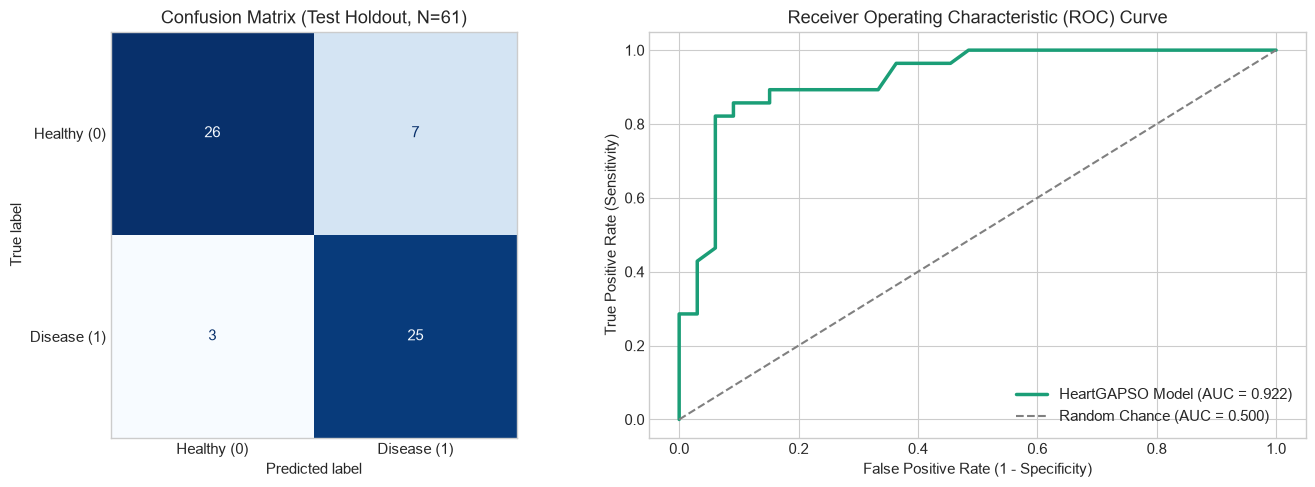

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Display
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Healthy (0)", "Disease (1)"]
)
cm_display.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix (Test Holdout, N={len(y_test)})")
axes[0].grid(False)

# 2. ROC Curve Display
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#1b9e77', lw=2.5, label=f'HeartGAPSO Model (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.500)')
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 9. Model Serialization & Artifacts Export
Exporting model binaries and detailed audit metadata to `models/`, `results/`, and `artifacts/` directories for deployment and record-keeping.


In [20]:
# Prepare paths
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("artifacts").mkdir(exist_ok=True)

# Build comprehensive evaluation report
report = {
    **metrics_summary,
    "selected_features": selected_feature_names,
    "number_selected_features": len(selected_feature_names),
    "best_rf_parameters": opt_result["params"],
    "optimization_fitness": opt_result["fitness"],
    "optimization_runtime_seconds": opt_runtime,
    "classification_threshold": opt_result["threshold"],
    "seed": RANDOM_SEED,
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
}

# Save serialized models and configs
with open("models/gapso_random_forest.pkl", "wb") as f:
    pickle.dump(pipeline, f)
with open("models/preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

Path("models/selected_features.json").write_text(json.dumps(selected_feature_names, indent=2))
Path("models/model_config.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/evaluation.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/metrics.json").write_text(json.dumps(report, indent=2, default=str))

# Save diagnostics plots to results
save_optimization_diagnostics(opt_result["history"], opt_result, "results")

print("✓ All models and metrics exported successfully:")
print(" - models/gapso_random_forest.pkl")
print(" - models/preprocessing.pkl")
print(" - models/selected_features.json")
print(" - models/model_config.json")
print(" - results/metrics.json")


✓ All models and metrics exported successfully:
 - models/gapso_random_forest.pkl
 - models/preprocessing.pkl
 - models/selected_features.json
 - models/model_config.json
 - results/metrics.json


## 10. Patient Inference Demo
Demonstration of scoring new patient records using the trained pipeline with calibrated probability output and decision thresholding.


In [21]:
# Sample patient clinical profiles
sample_patients = pd.DataFrame([
    {
        "Patient": "Patient A (High Risk Profile)",
        "age": 63, "sex": 1, "cp": 4, "trestbps": 145, "chol": 233, "fbs": 1,
        "restecg": 2, "thalach": 150, "exang": 1, "oldpeak": 2.3, "slope": 3,
        "ca": 2, "thal": 7
    },
    {
        "Patient": "Patient B (Low Risk Profile)",
        "age": 41, "sex": 0, "cp": 2, "trestbps": 120, "chol": 180, "fbs": 0,
        "restecg": 0, "thalach": 172, "exang": 0, "oldpeak": 0.0, "slope": 1,
        "ca": 0, "thal": 3
    }
])

# Extract feature columns only for inference
patient_features = sample_patients[FEATURE_NAMES]

# Predict risk probabilities and class
probabilities = pipeline.predict_proba(patient_features)[:, 1]
predictions = pipeline.predict(patient_features)

# Compile results table
results_table = []
for i, row in sample_patients.iterrows():
    prob = probabilities[i]
    pred = predictions[i]
    risk_level = "HIGH RISK (Disease Predicted)" if pred == 1 else "LOW RISK (Healthy Predicted)"
    results_table.append({
        "Patient Profile": row["Patient"],
        "Age": row["age"],
        "Sex": "Male" if row["sex"] == 1 else "Female",
        "Chest Pain (cp)": row["cp"],
        "Thalach (bpm)": row["thalach"],
        "Predicted Probability": f"{prob:.1%}",
        "Decision Threshold": f"{pipeline.threshold:.3f}",
        "Clinical Prediction": risk_level
    })

display(pd.DataFrame(results_table))


,Patient Profile,Age,Sex,Chest Pain (cp),Thalach (bpm),Predicted Probability,Decision Threshold,Clinical Prediction
0,Patient A (High Risk Profile),63,Male,4,150,81.7%,0.450,HIGH RISK (Disease Predicted)
1,Patient B (Low Risk Profile),41,Female,2,172,9.4%,0.450,LOW RISK (Healthy Predicted)


---
### ✅ Pipeline Execution Complete
The model is saved and ready for production inference via `predict.py` or within any Python service.
